# Detecting Data Drift with Statistical Tests

See [`docs/04-detecting-data-drift.md`](../docs/04-detecting-data-drift.md#statistical-tests) for the
concept notes this notebook is based on.

Statistical hypothesis tests answer a sharper question than summary statistics: is the difference
between `reference` and `current` large enough that it's unlikely to be random sampling noise? The
output is a **p-value** — a measure of confidence, not a distance.

All four notebooks in this folder analyze the exact same synthetic `reference`/`current` pair from
[`src/drift_dataset.py`](../src/drift_dataset.py), so results are directly comparable across techniques.

## Load the shared reference/current dataset

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import (
    CATEGORICAL_COLUMNS,
    COLUMN_DRIFT_GROUND_TRUTH,
    NUMERICAL_COLUMNS,
    make_reference_and_current,
)

pd.set_option("display.width", 120)

reference, current = make_reference_and_current(seed=42)
print("reference:", reference.shape, " current:", current.shape)
reference.head()

reference: (5000, 6)  current: (2000, 6)


,channel,product_category,basket_size,discount_pct,unit_price,customer_age
0,in_store,electronics,21.102831,0.031317,17.104594,32.639729
1,in_store,grocery,63.178040,0.062780,22.418914,46.994313
2,online,home,51.468098,0.173390,15.736280,43.558738
3,in_store,electronics,46.992552,0.189024,16.649926,52.330196
4,in_store,electronics,53.157178,0.080097,18.866577,44.449209


## Kolmogorov-Smirnov test (numerical features)

`scipy.stats.ks_2samp` tests whether two samples come from the same continuous distribution. Lower
p-values mean stronger evidence of a difference.

In [2]:
from scipy import stats

ALPHA = 0.05

def ks_table(ref, cur, columns, alpha=ALPHA):
    rows = []
    for col in columns:
        statistic, p_value = stats.ks_2samp(ref[col], cur[col])
        rows.append({
            "feature": col,
            "ks_statistic": statistic,
            "p_value": p_value,
            f"drift_detected (p < {alpha})": p_value < alpha,
        })
    return pd.DataFrame(rows).set_index("feature")

ks_result = ks_table(reference, current, NUMERICAL_COLUMNS)
ks_result

,ks_statistic,p_value,drift_detected (p < 0.05)
feature,,,
basket_size,0.2821,1.162272e-100,True
discount_pct,0.1449,1.321243e-26,True
unit_price,0.0287,1.870178e-01,False
customer_age,0.0224,4.650535e-01,False


## Chi-square test (categorical features)

`scipy.stats.chisquare` compares observed category counts in `current` against counts expected
under the `reference` proportions (rescaled to the `current` sample size). A category that is brand
new in `current` (like `online_exclusive`) has zero expected count under `reference` — we apply the
standard small-constant correction to keep the statistic finite, and separately report any new
categories found.

In [3]:
def chi2_table(ref, cur, columns, alpha=ALPHA):
    rows = []
    for col in columns:
        categories = sorted(set(ref[col]) | set(cur[col]))
        ref_counts = ref[col].value_counts().reindex(categories, fill_value=0)
        cur_counts = cur[col].value_counts().reindex(categories, fill_value=0)

        expected = ref_counts / ref_counts.sum() * cur_counts.sum()
        expected = expected.replace(0, 0.5)  # continuity correction for brand-new categories
        expected = expected / expected.sum() * cur_counts.sum()  # renormalize so totals match exactly

        statistic, p_value = stats.chisquare(f_obs=cur_counts, f_exp=expected)
        new_categories = sorted(set(cur[col]) - set(ref[col]))
        rows.append({
            "feature": col,
            "chi2_statistic": statistic,
            "p_value": p_value,
            f"drift_detected (p < {alpha})": p_value < alpha,
            "new_categories": new_categories,
        })
    return pd.DataFrame(rows).set_index("feature")

chi2_result = chi2_table(reference, current, CATEGORICAL_COLUMNS)
chi2_result

,chi2_statistic,p_value,drift_detected (p < 0.05),new_categories
feature,,,,
channel,1386.639485,1.681541e-303,True,[]
product_category,155210.465085,0.000000e+00,True,[online_exclusive]


## p-values at a glance

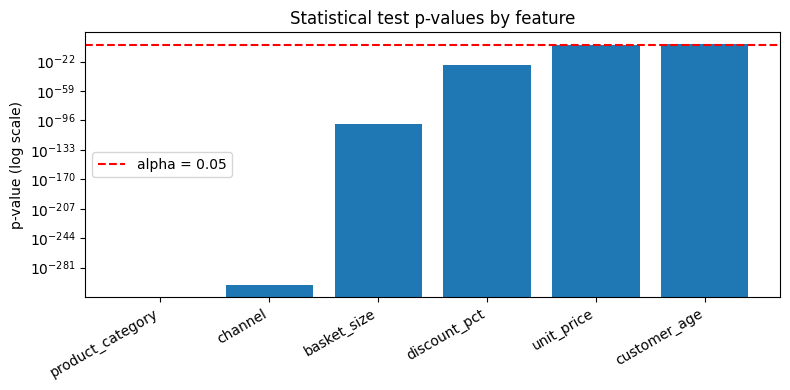

In [4]:
combined = pd.concat([ks_result["p_value"], chi2_result["p_value"]]).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(combined.index, combined.values)
ax.axhline(ALPHA, color="red", linestyle="--", label=f"alpha = {ALPHA}")
ax.set_yscale("log")
ax.set_ylabel("p-value (log scale)")
ax.set_title("Statistical test p-values by feature")
ax.legend()
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

## Sample-size sensitivity: statistical significance vs. practical significance

The docs note a caveat: *"if you can detect the difference with a relatively small sample, it's
likely important. Otherwise, the tests may be overly sensitive."* We check this directly with two
cases, resampling at growing sizes `n` and tracking the median KS p-value over repeated draws:

- **Case A — true null**: `unit_price` in `reference` vs. `current` (a control feature with *no*
  injected difference). We expect the p-value to stay noisy/high (around 0.5) at every `n`.
- **Case B — a small, real effect**: `discount_pct` in `reference` vs. `current` (a small but real
  mean shift, ~9.2% vs ~11.1%). We expect the p-value to only drop below alpha once `n` is large
  enough for the test to have the statistical power to detect it.

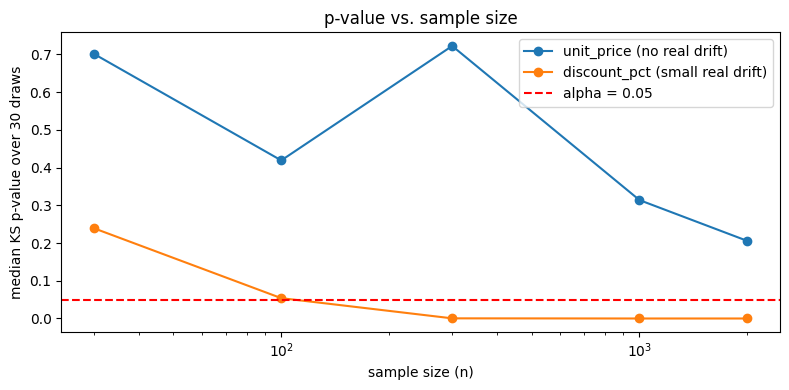

,n,median_p_value,share_significant,feature
0,30,0.701017,0.000000,unit_price
1,100,0.418847,0.100000,unit_price
2,300,0.722063,0.033333,unit_price
3,1000,0.313680,0.033333,unit_price
4,2000,0.205564,0.100000,unit_price


,n,median_p_value,share_significant,feature
0,30,2.390730e-01,0.166667,discount_pct
1,100,5.390208e-02,0.433333,discount_pct
2,300,4.014328e-04,0.933333,discount_pct
3,1000,3.695338e-10,1.000000,discount_pct
4,2000,2.184950e-19,1.000000,discount_pct


In [5]:
def subsample_ks_curve(a, b, sizes, repeats=30, seed=0):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    rows = []
    for n in sizes:
        p_values = []
        for _ in range(repeats):
            sample_a = rng.choice(a, size=min(n, len(a)), replace=False)
            sample_b = rng.choice(b, size=min(n, len(b)), replace=False)
            _, p_value = stats.ks_2samp(sample_a, sample_b)
            p_values.append(p_value)
        rows.append({
            "n": n,
            "median_p_value": np.median(p_values),
            "share_significant": np.mean(np.array(p_values) < ALPHA),
        })
    return pd.DataFrame(rows)

sizes = [30, 100, 300, 1000, 2000]
case_a = subsample_ks_curve(reference["unit_price"], current["unit_price"], sizes)
case_b = subsample_ks_curve(reference["discount_pct"], current["discount_pct"], sizes)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(case_a["n"], case_a["median_p_value"], marker="o", label="unit_price (no real drift)")
ax.plot(case_b["n"], case_b["median_p_value"], marker="o", label="discount_pct (small real drift)")
ax.axhline(ALPHA, color="red", linestyle="--", label=f"alpha = {ALPHA}")
ax.set_xscale("log")
ax.set_xlabel("sample size (n)")
ax.set_ylabel("median KS p-value over 30 draws")
ax.set_title("p-value vs. sample size")
ax.legend()
fig.tight_layout()
plt.show()

display(case_a.assign(feature="unit_price"))
display(case_b.assign(feature="discount_pct"))

`discount_pct`'s p-value only crosses the alpha line once `n` is in the high hundreds/low
thousands — exactly the "overly sensitive at scale" pattern the docs warn about. Whether that 2
percentage-point discount shift is *worth acting on* is a business call the p-value alone can't
make; `unit_price`, with no real difference, never reliably crosses the line no matter how much data
you throw at it.

## When to use statistical tests

- Best with a **small number of important, interpretable features**, smaller-to-moderate datasets,
  and **high-stakes domains** (healthcare, finance) where a rigorous same-distribution hypothesis
  test is worth the interpretability of a p-value.
- Choose the test to match the data: Kolmogorov-Smirnov for continuous numerical features,
  Chi-square for categorical ones — and check any distributional assumptions the test makes.
- Remember the caveat above: at large sample sizes, tests become sensitive to differences too small
  to matter practically. If you're running these on large production batches, distance metrics
  (`03_distance_metrics.ipynb`) are usually the better primary signal.

## Answer key

What this synthetic scenario was built to demonstrate for each column:

In [6]:
pd.Series(COLUMN_DRIFT_GROUND_TRUTH, name="ground_truth").to_frame()

,ground_truth
channel,drift
product_category,drift
basket_size,drift
discount_pct,borderline
unit_price,none
customer_age,data_quality
